Helper functions:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd
import torch
from scipy.integrate import solve_ivp
from collections.abc import Callable
from typing import Tuple

# Helper: wrap a PyTorch model that takes a torch tensor of shape (N,) or (N,1)
def make_torch_wrapper(pt_model, device="cpu", batch_dim=False):
    """
    Wrap a PyTorch model so it can be called as a numpy function u -> out (numpy array).
    - pt_model should accept a torch tensor of shape (N,) or (N,1) and return (N,) or (N,1)
    - device: 'cpu' or 'cuda'
    - batch_dim: if True, the model expects input shape (batch, N) or similar; keep False for elementwise
    Returns: callable(u_numpy) -> numpy array
    """
    pt_model.to(device)
    pt_model.eval()
    def wrapper(u_np: np.ndarray) -> np.ndarray:
        # Convert to torch tensor
        with torch.no_grad():
            u_t = torch.from_numpy(u_np.astype(np.float32)).to(device)
            # If model expects shape (N,1), reshape
            if u_t.ndim == 1:
                u_t_in = u_t.unsqueeze(1)  # (N,1)
            else:
                u_t_in = u_t
            out = pt_model(u_t_in)
            # If out has shape (N,1) or (N,), convert to 1D numpy
            out_np = out.detach().cpu().numpy()
            out_np = out_np.reshape(u_np.shape)
        return out_np
    return wrapper

# reconstruct the solution using the learned NN 'D_model' at the training points (x_train, t_train)
def recon_solution(x_train, t_train, D_model, u_NN_IC):
    D_callable = make_torch_wrapper(D_model, device='cpu')
    u_sim = simulate_pde(x_train, u_NN_IC, D_callable,
                       t_span=(t_train[0], t_train[-1]),
                       t_eval=t_train,
                       integrator="RK45")
    return u_sim

# Simulate the PDE u_t = (D(u) u_x)_x with Neumann BCs using method of lines and solve_ivp
def simulate_pde(x: np.ndarray,
                 IC: np.ndarray,
                 D_callable: Callable[[np.ndarray], np.ndarray],
                 t_span: Tuple[float, float] = (0.0, 20.0),
                 t_eval: np.ndarray = None,
                 integrator: str = "RK45",
                 rtol: float = 1e-6,
                 atol: float = 1e-8,
                 save_path: str = None):
    """
    Simulate FKPP with BC: u_x=0 at boundaries (note: not no-flux BCs!).
    Inputs:
      x           : 1D grid (numpy array)
      IC          : initial condition (numpy array same length as x)
      D_callable  : function(u_array) -> D_array (same length as u)
      t_span      : (t0, tf)
      t_eval      : times to evaluate solution; default 201 points between t0 and tf
      integrator  : "RK45" or "BDF" etc; BDF recommended if stiff
      rtol, atol  : tolerances for solve_ivp
      save_path   : optional path to save final u as npy
    Returns:
      sol : the SciPy OdeResult-like object from solve_ivp (sol.y shape (N, len(t_eval)))
    """
    
    x = np.asarray(x)
    N = x.size
    dx = x[1] - x[0]
    assert IC.shape == x.shape, "IC must match x shape"
    if t_eval is None:
        t_eval = np.linspace(t_span[0], t_span[1], 201)

    def rhs(t, u_vec):
        u = np.asarray(u_vec)

        # Evaluate D at nodes
        Dn = D_callable(u)
        if Dn.shape != u.shape:
            raise ValueError("D_callable must return array of same shape as u")

        # Build ghost-point extension for Neumann BCs: u_x = 0
        u_ext = np.empty(N + 2, dtype=u.dtype)
        u_ext[1:-1] = u
        u_ext[0] = u[1]      # left ghost cell: u_{-1} = u_1
        u_ext[-1] = u[-2]    # right ghost cell: u_N = u_{N-2}

        # Extend D consistently
        Dn_ext = np.empty(N + 2, dtype=Dn.dtype)
        Dn_ext[1:-1] = Dn
        Dn_ext[0] = Dn[1]
        Dn_ext[-1] = Dn[-2]

        # D at interfaces
        D_half = 0.5 * (Dn_ext[:-1] + Dn_ext[1:])   # length N+1

        # Fluxes at interfaces
        flux = D_half * (u_ext[1:] - u_ext[:-1]) / dx   # length N+1

        # Divergence at physical nodes
        diffusion_term = (flux[1:] - flux[:-1]) / dx

        return diffusion_term
        
    sol = solve_ivp(rhs, t_span, IC, method=integrator, t_eval=t_eval, rtol=rtol, atol=atol)

    if not sol.success:
        print("Warning: solver reported failure:", sol.message)
    if save_path is not None:
        np.save(save_path, sol.y[:, -1])
        print(f"Saved final state to {save_path}")

    return sol.y.T


Plot formatting & setups

In [2]:
# plot formatting
plt.rcParams['font.family'] = 'overall_overall_times New Roman'
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelweight'] = 'bold'  # Bold axis labels
plt.rcParams['axes.titleweight'] = 'bold'  # Bold title
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = str(20)
plt.rcParams['lines.linewidth'] = 2

# epochs for training history
epoch_hist = np.arange(0, 4001, 1)

# time resolutions
Nt, t_end, t_min = 7, 18, 0.0
t_train = np.linspace(t_min, t_end, Nt)

# spatial resolutions
L = 7.0
x_min, x_max = -L, L
dx = 0.04
x_train = np.arange(x_min, x_max+dx, dx)
Nx = len(x_train)

# true solutions
D_true = 0.5 # true diffusivity
xx, tt = np.meshgrid(x_train, t_train)
u_true = 0.5 * np.cos(np.pi * xx / L) * np.exp(-tt * D_true * (np.pi**2) / (L**2)) + 0.5 # so that u in [0, 1]
u_min_np, u_max_np = u_true.min(), u_true.max()
U_grid= np.linspace(u_min_np, u_max_np, Nx)

# the variances we used 
variances = [0, 1e-3, 5e-3, 1e-2, 5e-2]
seed = 8

NumRep = 10

top_load_folder = '../ARCresults/Diffusion_linear/'
top_save_folder = '../Figures/Fig2/'


u_structs = [r'$(4, 32)$', r'$(6, 128)$']

Loop through variances to store the L2RE of u_NN and u_reconstr

In [3]:
# for each variance, we have 10 repetitions with different random seeds for noise generation; 
# within each repetition, we run BINNs 10 times based on different BINNs initializations 
seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] 
subfolders = ['uStruct4_32/', 'uStruct6_128/']


# We are focusing on 2 u_Net architectures: (4 layers, 32 neurons/layer) and (6 layers, 128 neurons/layer);
# Each with 5 noise levels. 
# So we store the results in a list of sublist of shape(2, 5)
errorS_uNN = [[[] for _ in range(len(variances))] for _ in range(len(subfolders))]
errorS_u_reconstr = [[[] for _ in range(len(variances))] for _ in range(len(subfolders))]
u_pred_all = [[[] for _ in range(len(variances))] for _ in range(len(subfolders))]

for n, var in enumerate(variances):

    noise = np.sqrt(var)

    for s in seeds:
        np.random.seed(seed)
        u_true_noisy = u_true.copy() + noise * np.random.randn(*np.shape(u_true))
        _subfolder = f'additive_noise_seed{s}/'

        for subfolder in subfolders:

            sub_list_u_NNError, sub_list_u_reconstrError, sub_list_u_pred = [], [], []

            for rep in range(NumRep):
                # load the best D_model for this variance and this repetition
                D_model = torch.load(top_load_folder + _subfolder + subfolder + f'var{var}/Iter{rep}/D_net_best_Iter{rep}.pth', map_location=torch.device('cpu'), weights_only=False)
                # reconstruct the solution at the training points using the learned D_model
                u_netS = np.load(top_load_folder + _subfolder + subfolder + f'var{var}/u_predS.npy')
                u_NN = u_netS[rep, :, :]
                u_NN_IC = u_NN[0, :]
                u_sim = recon_solution(x_train, t_train, D_model, u_NN_IC)
                sub_list_u_pred.append(u_sim)
                

                # compute the L2RE of the reconstructed solution at the training points
                error_u_constructD = np.sqrt(np.sum((u_sim - u_true)**2)) / np.sqrt(np.sum(u_true**2))
                sub_list_u_reconstrError.append(error_u_constructD)
            
                # compute the L2RE of the solution learned by BINNs
                l2re_u = np.sqrt(np.sum((u_NN - u_true)**2)) / np.sqrt(np.sum(u_true**2))
                sub_list_u_NNError.append(l2re_u)

            errorS_uNN[subfolders.index(subfolder)][n].append(sub_list_u_NNError)
            errorS_u_reconstr[subfolders.index(subfolder)][n].append(sub_list_u_reconstrError)
            u_pred_all[subfolders.index(subfolder)][n].append(sub_list_u_pred)

errorS_uNN, errorS_u_reconstr, u_pred_all = np.array(errorS_uNN), np.array(errorS_u_reconstr), np.array(u_pred_all)

# save the results as .npy files for later plotting
np.save(top_save_folder + 'errorS_uNN_updated.npy', errorS_uNN)
np.save(top_save_folder + 'errorS_u_reconstr_updated.npy', errorS_u_reconstr)
np.save(top_save_folder + 'u_pred_all_updated.npy', u_pred_all)


### Plot: L2RE of u_NN wrt variances

(2, 5, 10, 10)


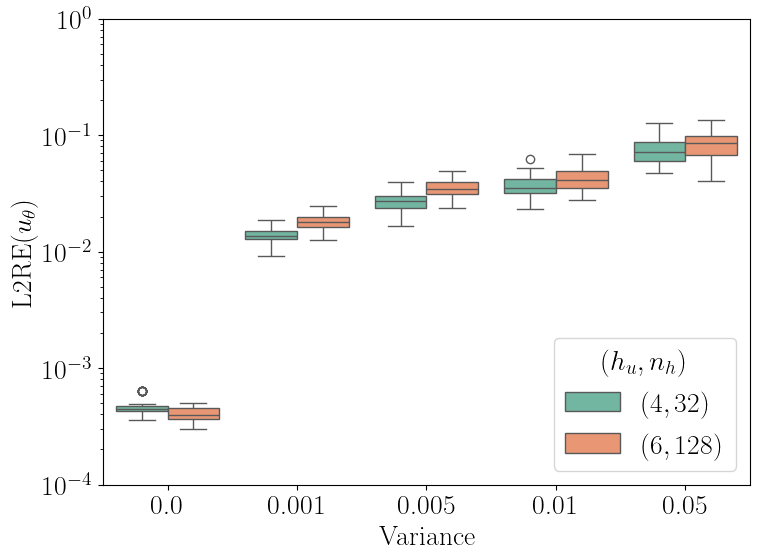

In [4]:

colors = sns.color_palette("Set2", len(u_structs))
NumRep = 10

# load errors
errorS_u = np.load(top_save_folder + 'errorS_uNN_updated.npy')
print(errorS_u.shape) # should be (2, 5, 10, 10) for (num_structs, num_variances, num_seeds, num_reps)

fig1, ax1 = plt.subplots(figsize=(8, 6))
data = []
# we have 10 additive noise seeds, and for each seed we have 10 repetitions of training BINNs;
for n in range(len(variances)):
    for s in range(len(subfolders)):
        for seed in seeds:
            for rep in range(NumRep):
                data.append([variances[n], errorS_u[s][n][seed-1][rep], u_structs[s]])


df = pd.DataFrame(data, columns=['Variance', r'L2RE($u_{\theta}$)', r'$(h_u, n_h)$'])
sns.boxplot(x='Variance', y=r'L2RE($u_{\theta}$)', hue=r'$(h_u, n_h)$', data=df, palette=colors, ax=ax1)
ax1.set_yscale('log')
ax1.set_ylim(1e-4, 1e0)
ax1.legend(loc ='lower right', title ='$(h_u, n_h)$')
fig1.tight_layout()
plt.show()

# save the figure as .svg file
fig1.savefig(top_save_folder + 'L2RE_uNN_updated.svg', format='svg', bbox_inches='tight')

### Plot L2RE of u_reconstr wrt variances

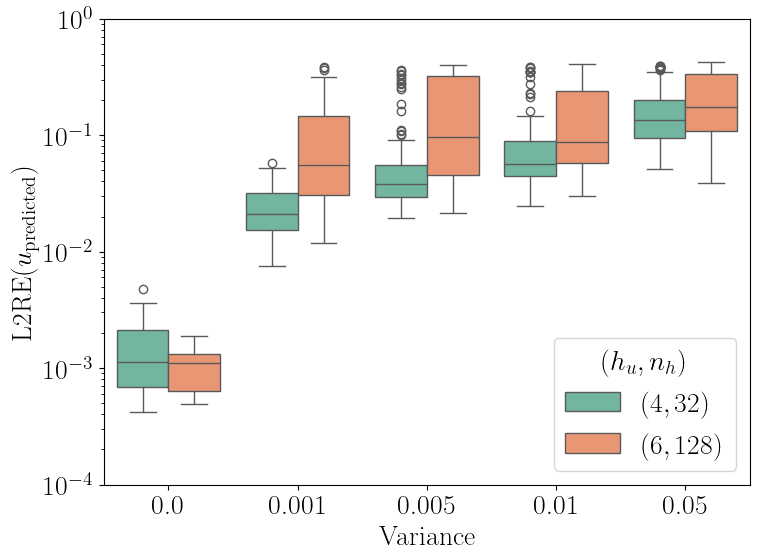

In [5]:

colors = sns.color_palette("Set2", len(u_structs))

# load errors
errorS_u_reconstr = np.load(top_save_folder + 'errorS_u_reconstr_updated.npy')

fig2, ax2 = plt.subplots(figsize=(8, 6))
data = []
for n in range(len(variances)):
    for s in range(len(subfolders)):
        for seed in seeds:
            for rep in range(NumRep):
                data.append([variances[n], errorS_u_reconstr[s][n][seed-1][rep], u_structs[s]])
df = pd.DataFrame(data, columns=['Variance', r'L2RE($u_{\mathrm{predicted}}$)', r'$(h_u, n_h)$'])
sns.boxplot(x='Variance', y=r'L2RE($u_{\mathrm{predicted}}$)', hue=r'$(h_u, n_h)$', data=df, palette=colors, ax=ax2)
ax2.set_yscale('log')
ax2.set_ylim(1e-4, 1e0)
ax2.legend(loc ='lower right', title ='$(h_u, n_h)$')
fig2.tight_layout()
plt.show()

# save the figure as .svg file
fig2.savefig(top_save_folder + 'L2RE_ureconstr_updated.svg', format='svg', bbox_inches='tight')